## Import Library

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, json, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPool1D, Conv1D,
    MaxPooling1D, BatchNormalization, Flatten, GlobalAveragePooling1D,
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)

### Inisiasi Nilai Konstanta

In [26]:
RANDOM_SEED   = 42
NUM_WORDS     = 10000
MAX_LENGTH    = 200
EMBED_DIM     = 128
EPOCH         = 50
BATCH_SIZE    = 32
OUTPUT_DIR = './models'
LOGS_DIR   = './logs'

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

## Load Dataset

In [27]:
df = pd.read_excel(r"D:\Kuliah\DICODING\Capstone\HealMate_AI\DS\Empathetic Counseling Dataset\Empathetic Counseling.xlsx")
print(f'Shape : {df.shape}')
df.head()

Shape : (1336, 10)


,input_clean,label_clean,input_no_punct,label_no_punct,breakup_score,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,my fiance and i have been together for 3 years...,finding out about an affair is quite an emotio...,my fiance and i have been together for 3 years...,finding out about an affair is quite an emotio...,4,0.133414,0.597922,0.268664,anxiety,0.597922
1,i caught my wife red handed cheating on me i f...,i could not move my body. i fainted because sh...,i caught my wife red handed cheating on me i f...,i could not move my body i fainted because she...,2,0.576117,0.211942,0.211942,anger,0.576117
2,we live with my ex partners sister and her hus...,"hi new york, i am happy to hear that your daug...",we live with my ex partners sister and her hus...,hi new york i am happy to hear that your daugh...,2,0.576117,0.211942,0.211942,anger,0.576117
3,"hello, i have a cousin in my family who has be...",it sounds like you are feeling pretty criticiz...,hello i have a cousin in my family who has bee...,it sounds like you are feeling pretty criticiz...,2,0.785597,0.175290,0.039113,anger,0.785597
4,i am concerned about my current long distance ...,it is important to communicate your concerns w...,i am concerned about my current long distance ...,it is important to communicate your concerns w...,4,0.576117,0.211942,0.211942,anger,0.576117


## Exploratory Data Analysis

In [28]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplikat : {df.duplicated().sum()}')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   input_clean         1336 non-null   str    
 1   label_clean         1336 non-null   str    
 2   input_no_punct      1336 non-null   str    
 3   label_no_punct      1336 non-null   str    
 4   breakup_score       1336 non-null   int64  
 5   anger_prob          1336 non-null   float64
 6   anxiety_prob        1336 non-null   float64
 7   acceptance_prob     1336 non-null   float64
 8   predicted_emotion   1336 non-null   str    
 9   emotion_confidence  1336 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 104.5 KB

Missing values:
input_clean           0
label_clean           0
input_no_punct        0
label_no_punct        0
breakup_score         0
anger_prob            0
anxiety_prob          0
acceptance_prob       0
predicted_emotion     0
emotion_confidence    0

,breakup_score,anger_prob,anxiety_prob,acceptance_prob,emotion_confidence
count,1336.000000,1336.000000,1336.000000,1336.000000,1336.000000
mean,2.448353,0.355560,0.347360,0.297081,0.545280
std,0.863941,0.191219,0.184883,0.168202,0.145423
min,2.000000,0.000335,0.000911,0.009368,0.344535
25%,2.000000,0.211942,0.211942,0.211942,0.451863
50%,2.000000,0.327732,0.344535,0.239694,0.576117
75%,3.000000,0.576117,0.451863,0.327732,0.576117
max,9.000000,0.979748,0.980098,0.998754,0.998754


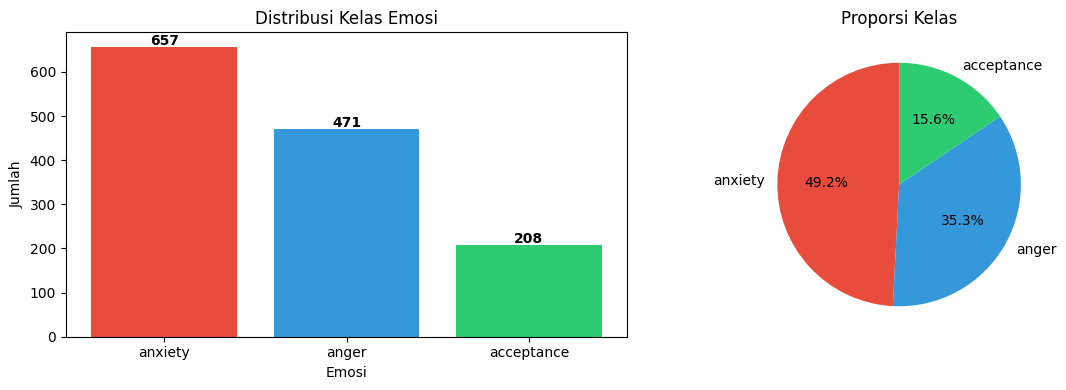

predicted_emotion
anxiety       657
anger         471
acceptance    208
Name: count, dtype: int64


In [29]:
# ── Distribusi Kelas ─────────────────────────────────────────
label_counts = df['predicted_emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db', '#2ecc71'],
            startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()
print(label_counts)

## Split Data

In [30]:
X = df['input_clean'].fillna('').astype(str)
y = df['predicted_emotion']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {i}')

Label encoding:
  acceptance   → 0
  anger        → 1
  anxiety      → 2


In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nData split:')
print(f'  Train set : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val set   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

# Simpan index train untuk mapping retrieval
train_indices = X_train.index.tolist()
print(f'\n✅ Index train disimpan untuk mapping retrieval ({len(train_indices)} baris)')


Data split:
  Train set : 1,068 samples (79.9%)
  Val set   : 134 samples (10.0%)
  Test set  : 134 samples (10.0%)

✅ Index train disimpan untuk mapping retrieval (1068 baris)


## Tokenisasi dan Padding

In [32]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = min(len(tokenizer.word_index) + 1, NUM_WORDS)
print(f'Vocab size (aktual) : {len(tokenizer.word_index):,}')
print(f'Vocab size (capped) : {vocab_size:,}')

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LENGTH, padding='post', truncating='post')

X_train_seq = texts_to_padded(X_train)
X_val_seq   = texts_to_padded(X_val)
X_test_seq  = texts_to_padded(X_test)

print(f'\nShape setelah padding:')
print(f'  Train : {X_train_seq.shape}')
print(f'  Val   : {X_val_seq.shape}')
print(f'  Test  : {X_test_seq.shape}')

Vocab size (aktual) : 3,031
Vocab size (capped) : 3,032

Shape setelah padding:
  Train : (1068, 200)
  Val   : (134, 200)
  Test  : (134, 200)


## Ekstraksi Fitur

### TF-IDF

In [33]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)
print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')

smote_tfidf = SMOTE(random_state=RANDOM_SEED)
X_train_tfidf_smote, y_train_tfidf_smote = smote_tfidf.fit_resample(X_train_tfidf, y_train)

print('\nSMOTE TF-IDF — distribusi setelah resampling:')
unique, counts = np.unique(y_train_tfidf_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(y_train_tfidf_smote):,}')

TF-IDF matrix shape: (1068, 3630)

SMOTE TF-IDF — distribusi setelah resampling:
  acceptance  : 525
  anger       : 525
  anxiety     : 525
  Total: 1,575


### CountVectorizer

In [34]:
count_vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X_train_count = count_vectorizer.fit_transform(X_train)
X_val_count   = count_vectorizer.transform(X_val)
X_test_count  = count_vectorizer.transform(X_test)
print(f'Count matrix shape: {X_train_count.shape}')

smote_count = SMOTE(random_state=RANDOM_SEED)
X_train_count_smote, y_train_count_smote = smote_count.fit_resample(X_train_count, y_train)

print('\nSMOTE Count — distribusi setelah resampling:')
unique, counts = np.unique(y_train_count_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(y_train_count_smote):,}')

Count matrix shape: (1068, 3630)

SMOTE Count — distribusi setelah resampling:
  acceptance  : 525
  anger       : 525
  anxiety     : 525
  Total: 1,575


## Modeling

### Helper Function

In [35]:



def callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{OUTPUT_DIR}/best_{model_name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                          min_lr=1e-6, verbose=1),
        TensorBoard(log_dir=f'{LOGS_DIR}/{model_name}', histogram_freq=0,
                    write_graph=False, update_freq='epoch'),
    ]

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

def train_model(model, model_name, X_train, y_train, X_val, y_val, epochs=EPOCH, batch_size=BATCH_SIZE):
    print(f'Training {model_name}...')
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights_dict,
        callbacks=callbacks(model_name)
    )
    best_epoch = int(np.argmax(history.history['val_accuracy'])) + 1
    print(f'\n✅ {model_name} selesai di epoch {len(history.history["accuracy"])}, best epoch: {best_epoch}')
    return model, history


def evaluate_dl_model(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_test, y_pred_classes)
    f1  = f1_score(y_test, y_pred_classes, average='weighted')
    print(f'\n{model_name} — Accuracy: {acc:.4f}, F1-Score: {f1:.4f}')
    print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, f1


def evaluate_sklearn_model(model, X_test, y_test, model_name='Model'):
    y_pred_classes = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_classes)
    f1  = f1_score(y_test, y_pred_classes, average='weighted')
    print(f'\n{model_name} — Accuracy: {acc:.4f}, F1-Score: {f1:.4f}')
    print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, f1


def plot_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric, title in zip(axes,
        [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
        [f'{model_name} — Accuracy', f'{model_name} — Loss']):
        ax.plot(history.history[metric[0]], label='Train')
        ax.plot(history.history[metric[1]], label='Validation')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print('✅ Helper functions ready!')

✅ Helper functions ready!


## Model Functions

In [36]:
NUM_CLASSES = len(le.classes_)
def model_LogisticRegression():
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_LinearSVC():
    model = LinearSVC(random_state=RANDOM_SEED, max_iter=10000)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_MultinomialNB():
    model = MultinomialNB()
    model.fit(X_train_count_smote, y_train_count_smote)
    return model

def model_RandomForest():
    model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_LSTM():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        LSTM(128, return_sequences=True),
        Dropout(0.5),
        LSTM(64),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_GRU():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        GRU(128, return_sequences=True),
        Dropout(0.5),
        GRU(64),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_CNN():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Conv1D(128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_BiLSTM():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.5),
        GlobalMaxPool1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_CNN_BiLSTM():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Conv1D(128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_CNN_BiLSTM_BatchNorm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Conv1D(128, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print('✅ Model functions ready!')

✅ Model functions ready!


 Logistic Regression 

Logistic Regression — Accuracy: 0.8582, F1-Score: 0.8576
              precision    recall  f1-score   support

  acceptance       0.74      0.81      0.77        21
       anger       0.95      0.77      0.85        47
     anxiety       0.85      0.94      0.89        66

    accuracy                           0.86       134
   macro avg       0.85      0.84      0.84       134
weighted avg       0.87      0.86      0.86       134



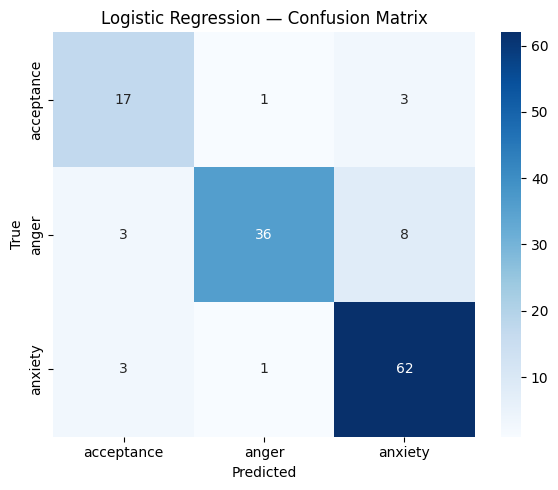

Logistic Regression - Test Acc: 0.8582, F1: 0.8576


In [37]:
# Logistic Regression
logreg_model = model_LogisticRegression()

print("="*50)
print(" Logistic Regression ")
print("="*50)

test_acc_logreg, test_f1_logreg = evaluate_sklearn_model(logreg_model, X_test_tfidf, y_test, "Logistic Regression")
print(f'Logistic Regression - Test Acc: {test_acc_logreg:.4f}, F1: {test_f1_logreg:.4f}')

 LinearSVC 

LinearSVC — Accuracy: 0.8731, F1-Score: 0.8725
              precision    recall  f1-score   support

  acceptance       0.75      0.71      0.73        21
       anger       0.95      0.85      0.90        47
     anxiety       0.86      0.94      0.90        66

    accuracy                           0.87       134
   macro avg       0.85      0.83      0.84       134
weighted avg       0.88      0.87      0.87       134



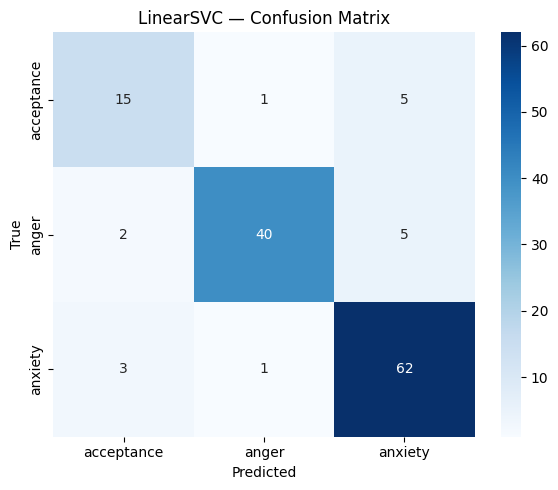

LinearSVC - Test Acc: 0.8731, F1: 0.8725


In [38]:
# LinearSVC
linear_svc_model = model_LinearSVC()

print("="*50)
print(" LinearSVC ")
print("="*50)

test_acc_linear_svc, test_f1_linear_svc = evaluate_sklearn_model(linear_svc_model, X_test_tfidf, y_test, "LinearSVC")
print(f'LinearSVC - Test Acc: {test_acc_linear_svc:.4f}, F1: {test_f1_linear_svc:.4f}')

 Multinomial Naive Bayes 

Multinomial Naive Bayes — Accuracy: 0.8209, F1-Score: 0.8209
              precision    recall  f1-score   support

  acceptance       0.71      0.71      0.71        21
       anger       0.83      0.83      0.83        47
     anxiety       0.85      0.85      0.85        66

    accuracy                           0.82       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.82      0.82      0.82       134



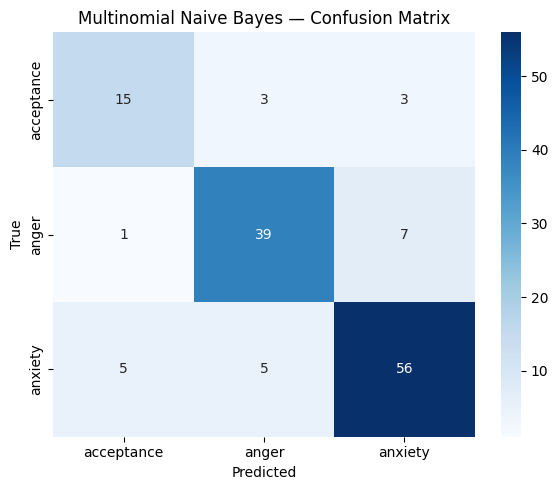

Multinomial Naive Bayes - Test Acc: 0.8209, F1: 0.8209


In [39]:
# Multinomial Naive Bayes
multinomial_nb_model = model_MultinomialNB()

print("="*50)
print(" Multinomial Naive Bayes ")
print("="*50)

test_acc_multinomial_nb, test_f1_multinomial_nb = evaluate_sklearn_model(multinomial_nb_model, X_test_count, y_test, "Multinomial Naive Bayes")
print(f'Multinomial Naive Bayes - Test Acc: {test_acc_multinomial_nb:.4f}, F1: {test_f1_multinomial_nb:.4f}')

 Random Forest 

Random Forest — Accuracy: 0.9030, F1-Score: 0.8969
              precision    recall  f1-score   support

  acceptance       1.00      0.57      0.73        21
       anger       0.98      0.91      0.95        47
     anxiety       0.85      1.00      0.92        66

    accuracy                           0.90       134
   macro avg       0.94      0.83      0.86       134
weighted avg       0.92      0.90      0.90       134



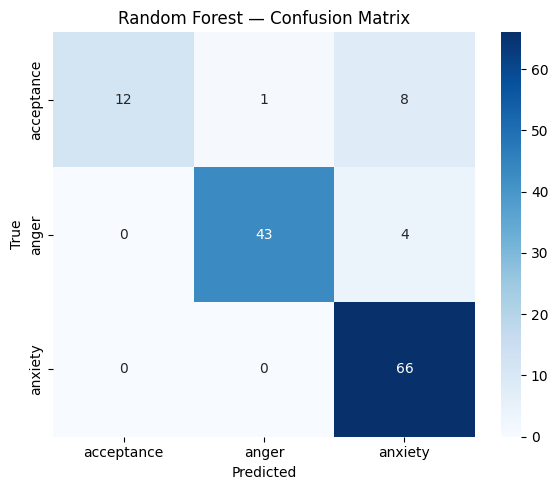

Random Forest - Test Acc: 0.9030, F1: 0.8969


In [40]:
# Random Forest
RF_model = model_RandomForest()

print("="*50)
print(" Random Forest ")
print("="*50)

test_acc_RF, test_f1_RF = evaluate_sklearn_model(RF_model, X_test_tfidf, y_test, "Random Forest")
print(f'Random Forest - Test Acc: {test_acc_RF:.4f}, F1: {test_f1_RF:.4f}')

 LSTM 
Training LSTM...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.3904 - loss: 1.1026 - val_accuracy: 0.3657 - val_loss: 1.1022 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.3652 - loss: 1.0993 - val_accuracy: 0.3657 - val_loss: 1.1080 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.4045 - loss: 1.0975 - val_accuracy: 0.3657 - val_loss: 1.1017 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.3830 - loss: 1.1002 - val_accuracy: 0.3731 - val_loss: 1.0800 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.4036 - loss: 1.0790 - val_accuracy: 0.3731 - val_loss: 1.0824 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.4007 - loss: 1.0686 - val_accuracy: 0.4776 - val_loss: 1.0681 - learning_rate: 0.0010
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.4

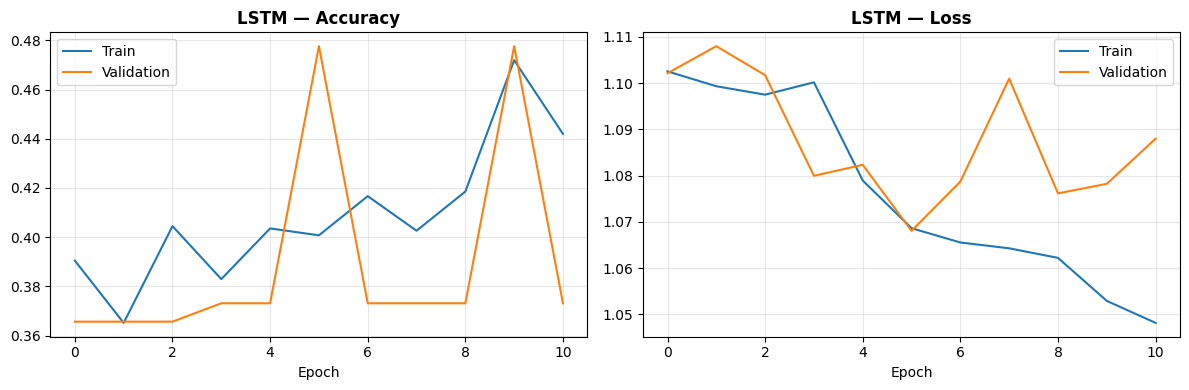


LSTM — Accuracy: 0.5224, F1-Score: 0.3855
              precision    recall  f1-score   support

  acceptance       1.00      0.14      0.25        21
       anger       1.00      0.02      0.04        47
     anxiety       0.51      1.00      0.67        66

    accuracy                           0.52       134
   macro avg       0.84      0.39      0.32       134
weighted avg       0.76      0.52      0.39       134



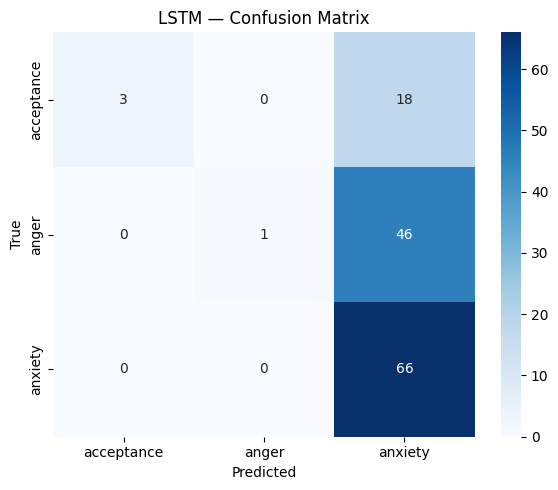

LSTM - Best Epoch: 6, Train Acc: 0.4007, Val Acc: 0.4776, Test Acc: 0.5224


In [41]:
# LSTM
lstm_model = model_LSTM()

print("="*50)
print(" LSTM ")
print("="*50)

lstm_model, lstm_history = train_model(lstm_model, 'LSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(lstm_history, 'LSTM')

best_epoch_lstm  = int(np.argmax(lstm_history.history['val_accuracy'])) + 1
train_acc_lstm   = lstm_history.history['accuracy'][best_epoch_lstm-1]
val_acc_lstm     = lstm_history.history['val_accuracy'][best_epoch_lstm-1]
test_acc_lstm, _ = evaluate_dl_model(lstm_model, X_test_seq, y_test, "LSTM")

print(f'LSTM - Best Epoch: {best_epoch_lstm}, Train Acc: {train_acc_lstm:.4f}, Val Acc: {val_acc_lstm:.4f}, Test Acc: {test_acc_lstm:.4f}')


 GRU 
Training GRU...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.3895 - loss: 1.1024 - val_accuracy: 0.3657 - val_loss: 1.1056 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.3642 - loss: 1.1020 - val_accuracy: 0.3657 - val_loss: 1.0957 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.3446 - loss: 1.0959 - val_accuracy: 0.1567 - val_loss: 1.1038 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.3783 - loss: 1.0913 - val_accuracy: 0.3731 - val_loss: 1.0895 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.3146 - loss: 1.0859 - val_accuracy: 0.3731 - val_loss: 1.0806 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.3811 - loss: 1.0759 - val_accuracy: 0.3731 - val_loss: 1.0979 - learning_rate: 0.0010
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0

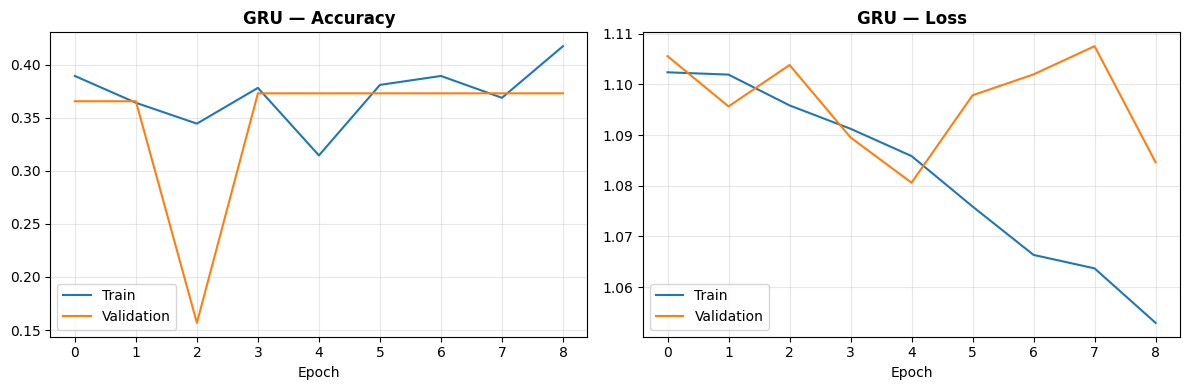


GRU — Accuracy: 0.3806, F1-Score: 0.2402
              precision    recall  f1-score   support

  acceptance       1.00      0.14      0.25        21
       anger       0.36      1.00      0.53        47
     anxiety       1.00      0.02      0.03        66

    accuracy                           0.38       134
   macro avg       0.79      0.39      0.27       134
weighted avg       0.78      0.38      0.24       134



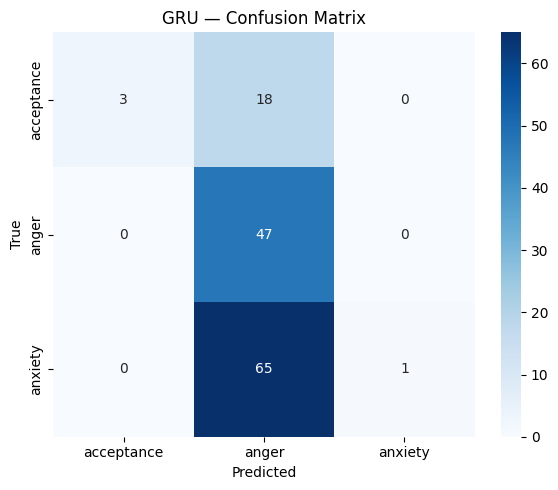

GRU - Best Epoch: 4, Train Acc: 0.3783, Val Acc: 0.3731, Test Acc: 0.3806


In [42]:
# GRU
gru_model = model_GRU()

print("\n" + "="*50)
print(" GRU ")
print("="*50)

gru_model, gru_history = train_model(gru_model, 'GRU', X_train_seq, y_train, X_val_seq, y_val)

plot_history(gru_history, 'GRU')

best_epoch_gru  = int(np.argmax(gru_history.history['val_accuracy'])) + 1
train_acc_gru   = gru_history.history['accuracy'][best_epoch_gru-1]
val_acc_gru     = gru_history.history['val_accuracy'][best_epoch_gru-1]
test_acc_gru, _ = evaluate_dl_model(gru_model, X_test_seq, y_test, "GRU")

print(f'GRU - Best Epoch: {best_epoch_gru}, Train Acc: {train_acc_gru:.4f}, Val Acc: {val_acc_gru:.4f}, Test Acc: {test_acc_gru:.4f}')


 CNN 
Training CNN...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3848 - loss: 1.0802 - val_accuracy: 0.3731 - val_loss: 1.0455 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5047 - loss: 0.9525 - val_accuracy: 0.5075 - val_loss: 0.9446 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6189 - loss: 0.7424 - val_accuracy: 0.6716 - val_loss: 0.7977 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7790 - loss: 0.4967 - val_accuracy: 0.7910 - val_loss: 0.6362 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8876 - loss: 0.2959 - val_accuracy: 0.8209 - val_loss: 0.5539 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9616 - loss: 0.1608 - val_accuracy: 0.7761 - val_loss: 0.5752 - learning_rate: 0.0010
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9757 -

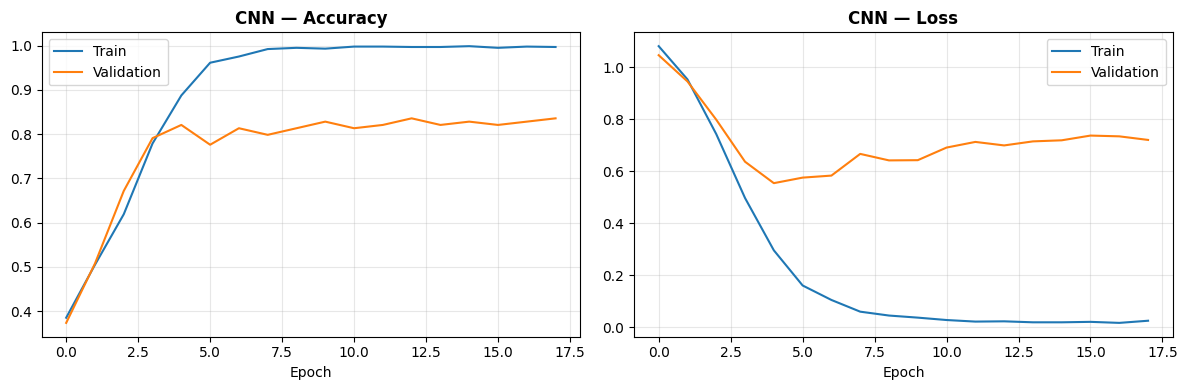


CNN — Accuracy: 0.7985, F1-Score: 0.7991
              precision    recall  f1-score   support

  acceptance       0.65      0.71      0.68        21
       anger       0.84      0.77      0.80        47
     anxiety       0.82      0.85      0.84        66

    accuracy                           0.80       134
   macro avg       0.77      0.78      0.77       134
weighted avg       0.80      0.80      0.80       134



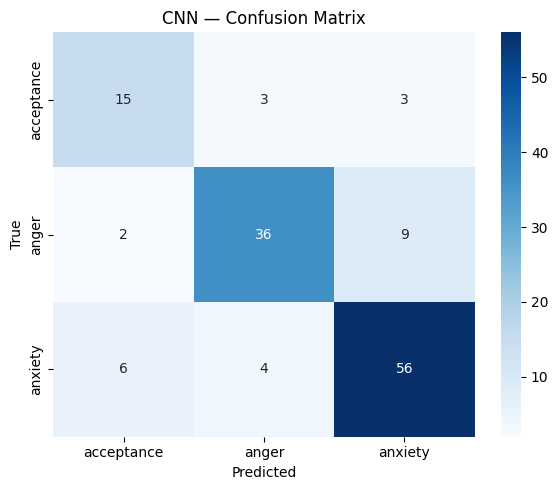

CNN - Best Epoch: 13, Train Acc: 0.9972, Val Acc: 0.8358, Test Acc: 0.7985


In [43]:
# CNN
cnn_model = model_CNN()

print("\n" + "="*50)
print(" CNN ")
print("="*50)

cnn_model, cnn_history = train_model(cnn_model, 'CNN', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_history, 'CNN')

best_epoch_cnn  = int(np.argmax(cnn_history.history['val_accuracy'])) + 1
train_acc_cnn   = cnn_history.history['accuracy'][best_epoch_cnn-1]
val_acc_cnn     = cnn_history.history['val_accuracy'][best_epoch_cnn-1]
test_acc_cnn, _ = evaluate_dl_model(cnn_model, X_test_seq, y_test, "CNN")

print(f'CNN - Best Epoch: {best_epoch_cnn}, Train Acc: {train_acc_cnn:.4f}, Val Acc: {val_acc_cnn:.4f}, Test Acc: {test_acc_cnn:.4f}')


 BiLSTM 
Training BiLSTM...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.3708 - loss: 1.0906 - val_accuracy: 0.3134 - val_loss: 1.1008 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.4663 - loss: 1.0169 - val_accuracy: 0.6269 - val_loss: 1.0082 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.6423 - loss: 0.7348 - val_accuracy: 0.7015 - val_loss: 0.8117 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.8502 - loss: 0.3780 - val_accuracy: 0.8134 - val_loss: 0.7312 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9382 - loss: 0.1851 - val_accuracy: 0.8060 - val_loss: 0.6208 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.9635 - loss: 0.1471 - val_accuracy: 0.7836 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accur

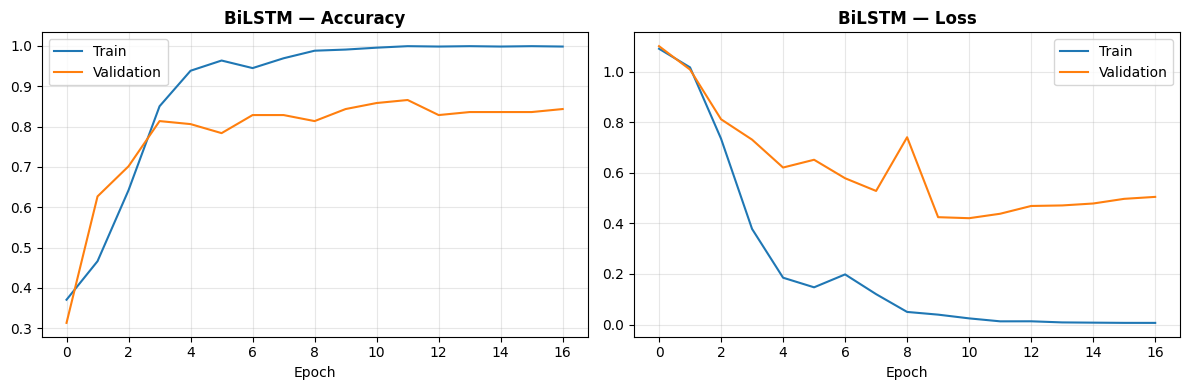


BiLSTM — Accuracy: 0.9030, F1-Score: 0.9014
              precision    recall  f1-score   support

  acceptance       0.94      0.71      0.81        21
       anger       0.96      0.91      0.93        47
     anxiety       0.86      0.95      0.91        66

    accuracy                           0.90       134
   macro avg       0.92      0.86      0.88       134
weighted avg       0.91      0.90      0.90       134



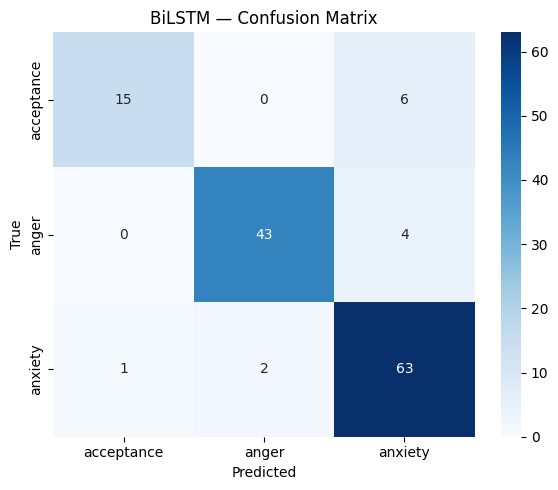

BiLSTM - Best Epoch: 12, Train Acc: 0.9991, Val Acc: 0.8657, Test Acc: 0.9030


In [44]:
# BiLSTM
bilstm_model = model_BiLSTM()

print("\n" + "="*50)
print(" BiLSTM ")
print("="*50)

bilstm_model, bilstm_history = train_model(bilstm_model, 'BiLSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(bilstm_history, 'BiLSTM')

best_epoch_bilstm  = int(np.argmax(bilstm_history.history['val_accuracy'])) + 1
train_acc_bilstm   = bilstm_history.history['accuracy'][best_epoch_bilstm-1]
val_acc_bilstm     = bilstm_history.history['val_accuracy'][best_epoch_bilstm-1]
test_acc_bilstm, _ = evaluate_dl_model(bilstm_model, X_test_seq, y_test, "BiLSTM")

print(f'BiLSTM - Best Epoch: {best_epoch_bilstm}, Train Acc: {train_acc_bilstm:.4f}, Val Acc: {val_acc_bilstm:.4f}, Test Acc: {test_acc_bilstm:.4f}')


 CNN + BiLSTM 
Training CNN_BiLSTM...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4139 - loss: 1.0897 - val_accuracy: 0.3507 - val_loss: 1.0137 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4345 - loss: 0.9747 - val_accuracy: 0.4552 - val_loss: 0.8845 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7228 - loss: 0.6003 - val_accuracy: 0.7313 - val_loss: 0.6656 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8764 - loss: 0.3290 - val_accuracy: 0.8060 - val_loss: 0.5420 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9541 - loss: 0.1547 - val_accuracy: 0.8134 - val_loss: 0.6772 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9757 - loss: 0.0848 - val_accuracy: 0.8060 - val_loss: 0.6713 - learning_rate: 0.0010
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - ac

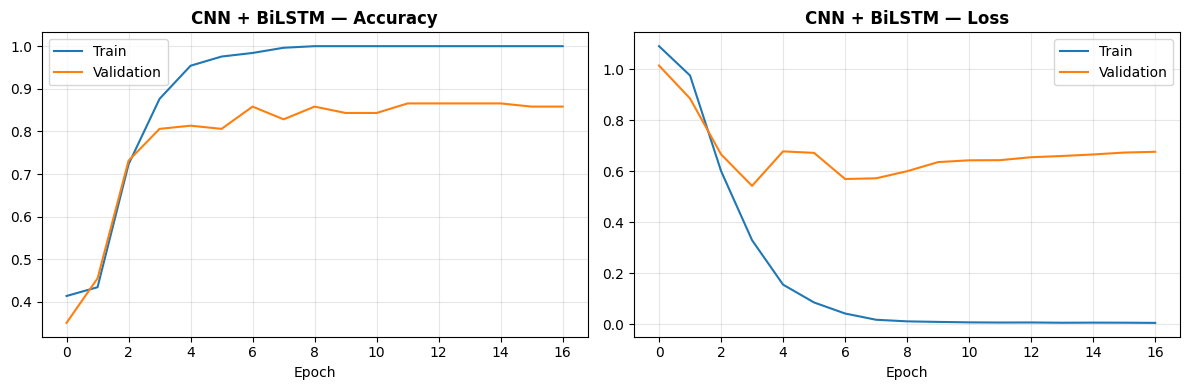


CNN + BiLSTM — Accuracy: 0.8806, F1-Score: 0.8792
              precision    recall  f1-score   support

  acceptance       0.79      0.71      0.75        21
       anger       0.89      0.87      0.88        47
     anxiety       0.90      0.94      0.92        66

    accuracy                           0.88       134
   macro avg       0.86      0.84      0.85       134
weighted avg       0.88      0.88      0.88       134



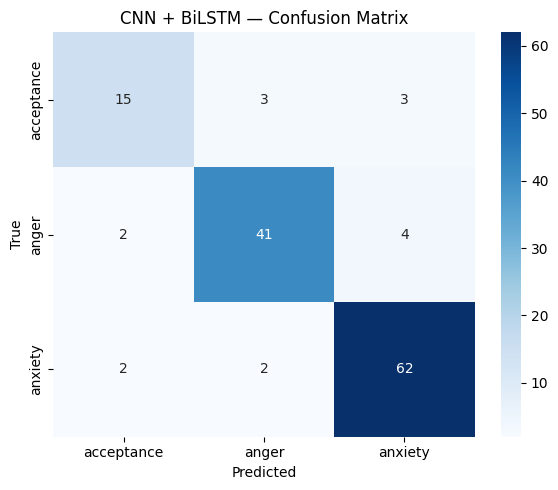

CNN + BiLSTM - Best Epoch: 12, Train Acc: 1.0000, Val Acc: 0.8657, Test Acc: 0.8806


In [45]:
# CNN + BiLSTM
cnn_bilstm_model = model_CNN_BiLSTM()

print("\n" + "="*50)
print(" CNN + BiLSTM ")
print("="*50)

cnn_bilstm_model, cnn_bilstm_history = train_model(cnn_bilstm_model, 'CNN_BiLSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_bilstm_history, 'CNN + BiLSTM')

best_epoch_cnn_bilstm  = int(np.argmax(cnn_bilstm_history.history['val_accuracy'])) + 1
train_acc_cnn_bilstm   = cnn_bilstm_history.history['accuracy'][best_epoch_cnn_bilstm-1]
val_acc_cnn_bilstm     = cnn_bilstm_history.history['val_accuracy'][best_epoch_cnn_bilstm-1]
test_acc_cnn_bilstm, _ = evaluate_dl_model(cnn_bilstm_model, X_test_seq, y_test, "CNN + BiLSTM")

print(f'CNN + BiLSTM - Best Epoch: {best_epoch_cnn_bilstm}, Train Acc: {train_acc_cnn_bilstm:.4f}, Val Acc: {val_acc_cnn_bilstm:.4f}, Test Acc: {test_acc_cnn_bilstm:.4f}')


 CNN + BiLSTM + BatchNorm 
Training CNN_BiLSTM_BN...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.4129 - loss: 1.0950 - val_accuracy: 0.5522 - val_loss: 1.0864 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6011 - loss: 0.8882 - val_accuracy: 0.6269 - val_loss: 1.0423 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7762 - loss: 0.5817 - val_accuracy: 0.6866 - val_loss: 0.9351 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9157 - loss: 0.2574 - val_accuracy: 0.7910 - val_loss: 0.8126 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9654 - loss: 0.1246 - val_accuracy: 0.6194 - val_loss: 0.7313 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9813 - loss: 0.0586 - val_accuracy: 0.5597 - val_loss: 0.8825 - learning_rate: 0.0010
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s

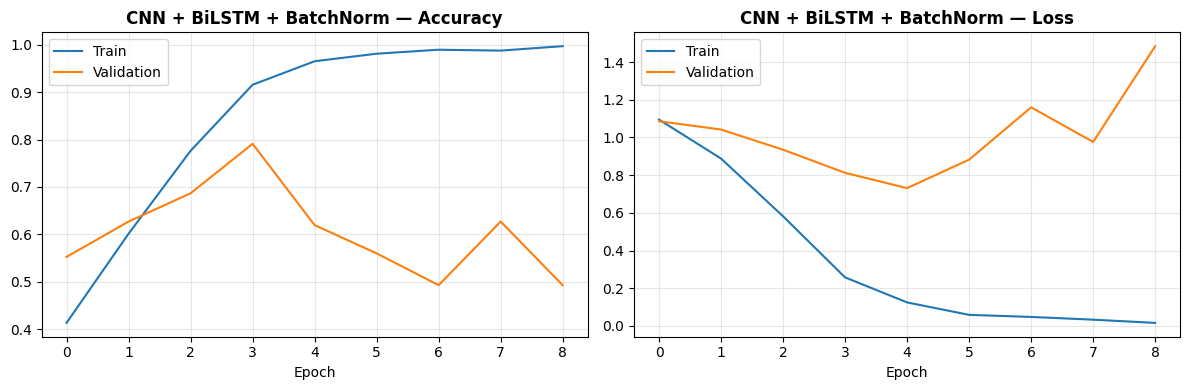


CNN + BiLSTM + BatchNorm — Accuracy: 0.7910, F1-Score: 0.7804
              precision    recall  f1-score   support

  acceptance       1.00      0.48      0.65        21
       anger       0.86      0.68      0.76        47
     anxiety       0.74      0.97      0.84        66

    accuracy                           0.79       134
   macro avg       0.87      0.71      0.75       134
weighted avg       0.82      0.79      0.78       134



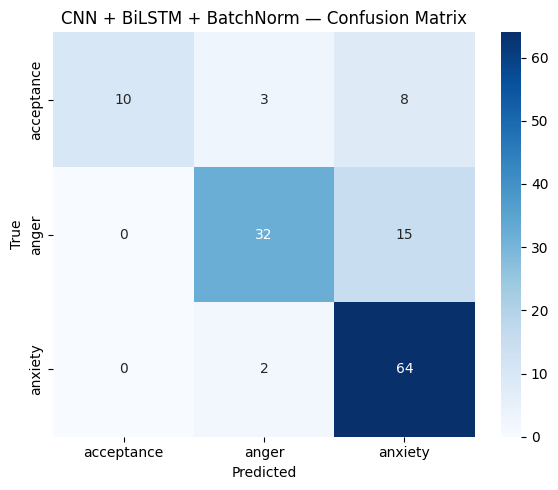

CNN+BiLSTM+BN - Best Epoch: 4, Train Acc: 0.9157, Val Acc: 0.7910, Test Acc: 0.7910


In [46]:
# CNN + BiLSTM + BatchNorm
cnn_bilstm_bn_model = model_CNN_BiLSTM_BatchNorm()

print("\n" + "="*50)
print(" CNN + BiLSTM + BatchNorm ")
print("="*50)

cnn_bilstm_bn_model, cnn_bilstm_bn_history = train_model(cnn_bilstm_bn_model, 'CNN_BiLSTM_BN', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_bilstm_bn_history, 'CNN + BiLSTM + BatchNorm')

best_epoch_cnn_bilstm_bn  = int(np.argmax(cnn_bilstm_bn_history.history['val_accuracy'])) + 1
train_acc_cnn_bilstm_bn   = cnn_bilstm_bn_history.history['accuracy'][best_epoch_cnn_bilstm_bn-1]
val_acc_cnn_bilstm_bn     = cnn_bilstm_bn_history.history['val_accuracy'][best_epoch_cnn_bilstm_bn-1]
test_acc_cnn_bilstm_bn, _ = evaluate_dl_model(cnn_bilstm_bn_model, X_test_seq, y_test, "CNN + BiLSTM + BatchNorm")

print(f'CNN+BiLSTM+BN - Best Epoch: {best_epoch_cnn_bilstm_bn}, Train Acc: {train_acc_cnn_bilstm_bn:.4f}, Val Acc: {val_acc_cnn_bilstm_bn:.4f}, Test Acc: {test_acc_cnn_bilstm_bn:.4f}')

## Evaluasi dan Metrics

In [47]:
print("=" * 50)
print(" Evaluasi Akhir ")
print("=" * 50)

models_info = [
    ('Logistic Regression',        test_acc_logreg),
    ('LinearSVC',                  test_acc_linear_svc),
    ('Multinomial Naive Bayes',    test_acc_multinomial_nb),
    ('Random Forest',              test_acc_RF),
    ('LSTM',                       test_acc_lstm),
    ('GRU',                        test_acc_gru),
    ('CNN',                        test_acc_cnn),
    ('BiLSTM',                     test_acc_bilstm),
    ('CNN + BiLSTM',               test_acc_cnn_bilstm),
    ('CNN + BiLSTM + BatchNorm',   test_acc_cnn_bilstm_bn),
]

print(f'{"Model":35s} | {"Test Accuracy":>12s}')
print("-" * 50)

for name, acc in models_info:
    print(f'{name:35s} | {acc:.4f}')

best_model_info = max(models_info, key=lambda x: x[1])
print("\nModel terbaik:", best_model_info[0], f"({best_model_info[1]:.4f})")

 Evaluasi Akhir 
Model                               | Test Accuracy
--------------------------------------------------
Logistic Regression                 | 0.8582
LinearSVC                           | 0.8731
Multinomial Naive Bayes             | 0.8209
Random Forest                       | 0.9030
LSTM                                | 0.5224
GRU                                 | 0.3806
CNN                                 | 0.7985
BiLSTM                              | 0.9030
CNN + BiLSTM                        | 0.8806
CNN + BiLSTM + BatchNorm            | 0.7910

Model terbaik: Random Forest (0.9030)


## Perbandingan

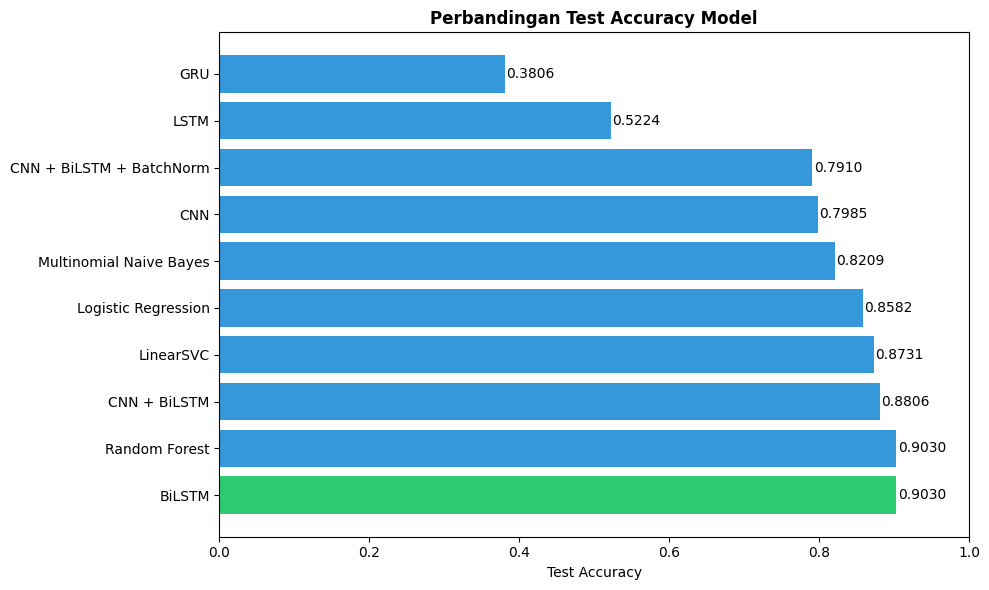

Model terbaik: BiLSTM (0.9030)


In [48]:
# Perbandingan performa model dan tampilkan model terbaik
df_results = pd.DataFrame(models_info, columns=['Model', 'TestAccuracy']).sort_values('TestAccuracy', ascending=False).reset_index(drop=True)

best = df_results.iloc[0]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == best['Model'] else '#3498db' for m in df_results['Model']]
bars = plt.barh(df_results['Model'], df_results['TestAccuracy'], color=colors)
for i, acc in enumerate(df_results['TestAccuracy']):
    plt.text(acc + 0.002, i, f'{acc:.4f}', va='center')
plt.title('Perbandingan Test Accuracy Model', fontweight='bold')
plt.xlabel('Test Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"Model terbaik: {best['Model']} ({best['TestAccuracy']:.4f})")